Saving mushrooms.csv to mushrooms (1).csv
===== Decision Tree =====
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



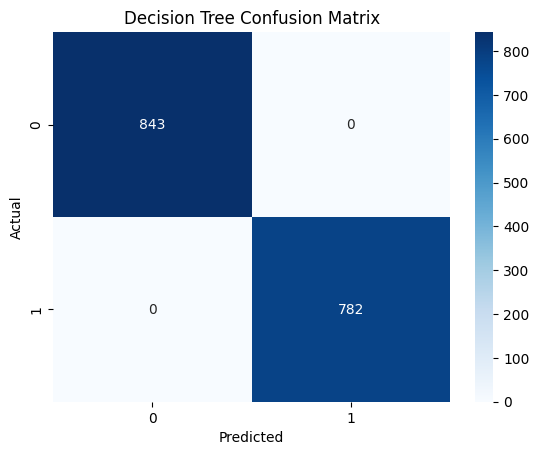

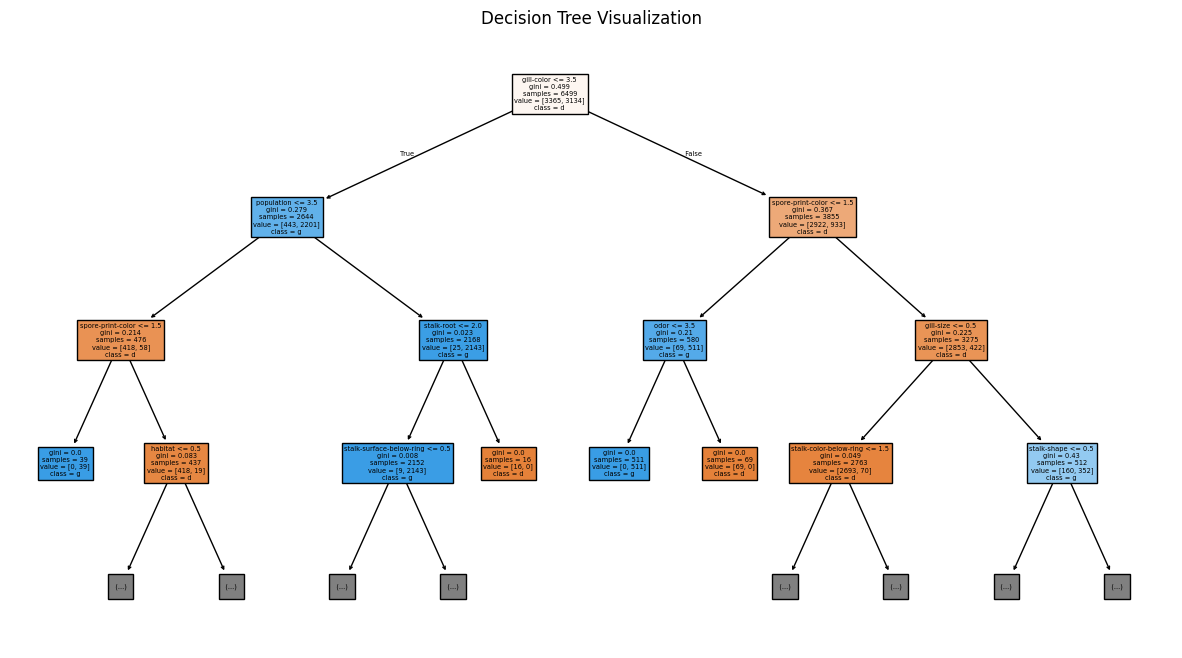

===== Tuned Decision Tree =====
Best Parameters: {'max_depth': 10, 'min_samples_split': 2}
Accuracy: 1.0


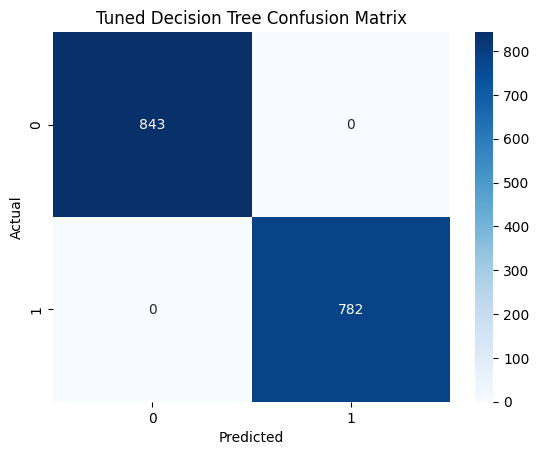

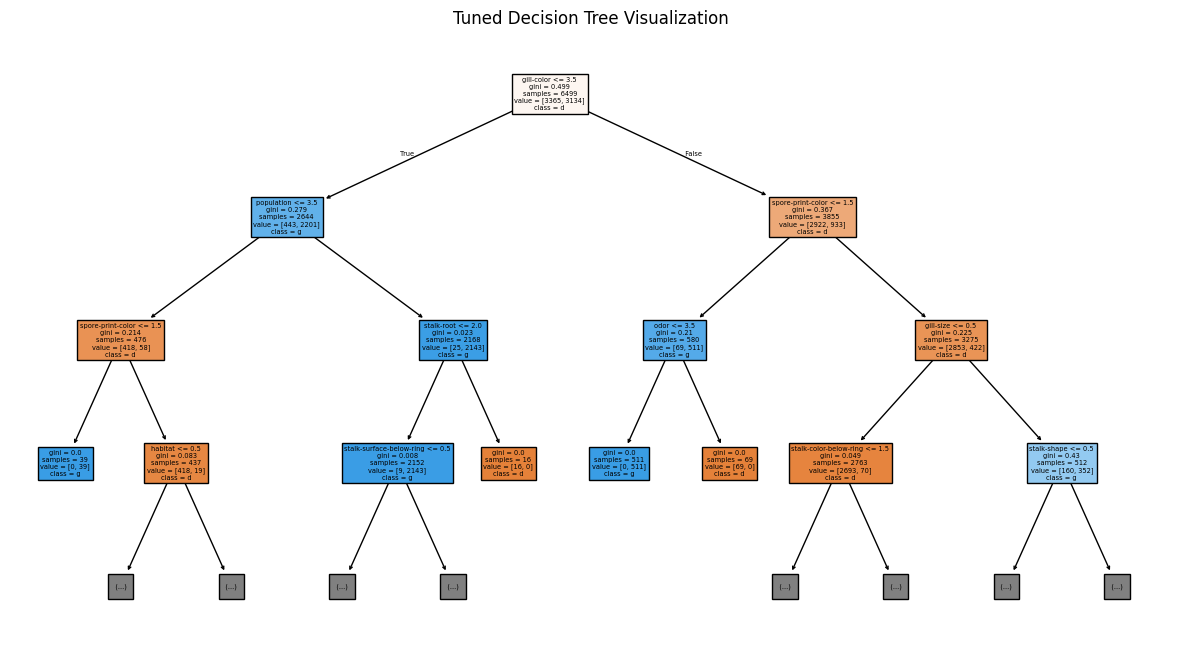

===== Random Forest =====
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



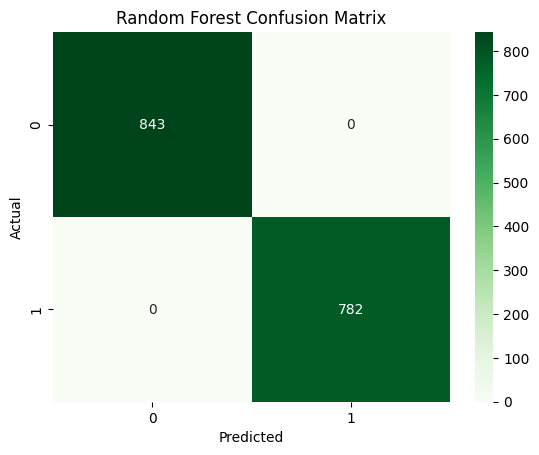

===== Tuned Random Forest =====
Best Parameters: {'max_depth': 10, 'n_estimators': 50}
Accuracy: 1.0


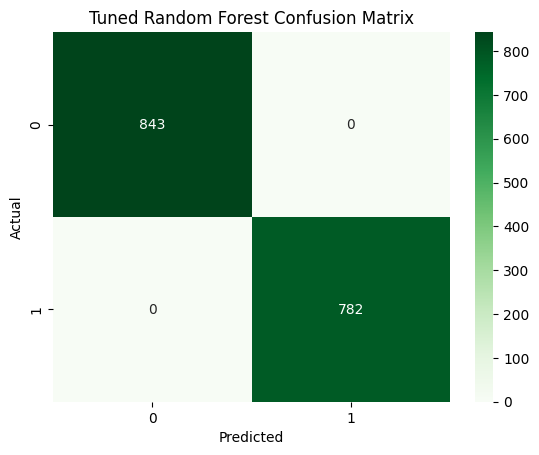

In [2]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("===== Decision Tree =====")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

plt.figure(figsize=(15,8))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=le.classes_,
    filled=True,
    max_depth=3
)
plt.title("Decision Tree Visualization")
plt.show()

params_dt = {
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 10]
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), params_dt, cv=5)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)

print("===== Tuned Decision Tree =====")
print("Best Parameters:", grid_dt.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_best_dt))

cm = confusion_matrix(y_test, y_pred_best_dt)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Decision Tree Confusion Matrix")
plt.show()

plt.figure(figsize=(15,8))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=le.classes_,
    filled=True,
    max_depth=3
)
plt.title("Tuned Decision Tree Visualization")
plt.show()

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

params_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), params_rf, cv=5)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("===== Tuned Random Forest =====")
print("Best Parameters:", grid_rf.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_best_rf))

cm = confusion_matrix(y_test, y_pred_best_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()